# Self-consistent random phase approximation optimized effective potential calculations

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  04/04/2026  
**Last modified:**  20/08/2026

## 1. Introduction

In this tutorial, I will present examples of self-consistent random phase approximation (SCRPA) optimized effective potential (OEP) calculations. These examples are intended to illustrate the main functionality and post-processing of calculations, such as plotting of resulting exchange, correlation and exchange-correlation potentials, accessing eigenvalues, etc.

---

The original implementation of the SCRPA method was described in
> P. Bleiziffer, A. Heßelmann, A. Görling. Efficient self-consistent treatment of electron correlation within the random phase approximation - J. Chem. Phys. 139, 084113 (2013). [link](https://doi.org/10.1063/1.4818984)

The latest state of the method originaly implemented in Molpro is described in
> E. Trushin, S. Fauser, A. Mölkner, J. Erhard, A. Görling. Accurate Correlation Potentials from the Self-Consistent Random Phase Approximation - Phys. Rev. Lett. 134, 016402 (2025). [link](https://doi.org/10.1103/PhysRevLett.134.016402)

The preprocessing of auxiliary basis set was described in
> E. Trushin, A. Görling. Numerically stable optimized effective potential method with standard Gaussian basis sets - J. Chem. Phys. 155, 054109 (2021). [link](https://doi.org/10.1063/5.0056431)  

---

<div class="alert alert-block alert-info"> <b>Important:</b> Read carefully the information below about the selection of basis sets and the thr_fai_oep parameter. </div>

SCRPA calculations requires to specify three basis sets, namely orbital, OEP, and RI basis sets. If density fitting is employed, the corresponding basis sets have to be also specified. The orbital basis set is the primary basis set for e.g. the representation of orbitals and the calculation of energy contributions. The OEP basis set is the auxiliary basis set for representing e.g. the exchange potential. The RI basis set is the basis set, in which the response matrix for the RPA energy calculation is represented. Gaussian basis set OEP methods for a long time suffered from numerical instabilities resulting from problems in balancing the orbital basis sets with the auxiliary basis sets. Present implementation of RPA-OEP uses a preprocessing of the auxiliary basis set that enables such balancing in an automatic fashion for standard Gaussian basis sets.The preprocessing step removes linear combinations of auxiliary basis functions that couple poorly to products of occupied times unoccupied Kohn-Sham orbitals. It involves the threshold `thr_fai_oep`, which determines how many linear combinations of auxiliary basis functions are removed and varies with respect to the size of the orbital basis set used. This scheme was tested using Dunning correlation consistent basis sets aug-cc-pwCVXZ (X = T, Q, 5) and recommended thresholds are

| Orbital basis set | **thr_fai_oep** |
| :----: | :----: |
| aug-cc-pwCVTZ  | $5 \cdot 10^{-2}$   |
| aug-cc-pwCVQZ  | $1.7 \cdot 10^{-2}$ |
| aug-cc-pwCV5Z  | $5 \cdot 10^{-3}$   |

These thresholds are also expected to work for orbital basis sets without augmentation cc-pwCVXZ (X = T, Q, 5) and without core-polarization functions aug-cc-pVXZ (X = T, Q, 5).

As an auxiliary basis set (OEP), the aug-cc-pVXZ/mp2fit (X = T, Q, 5) family of basis sets is recommended. In particular, it is recommended to use the aug-cc-pVDZ/mp2fit auxiliary basis sets for atoms up to neon and the aug-cc-pVTZ/mp2fit auxiliary basis sets for heavier atoms.

Def2 basis sets of Ahlrichs family of similar quality also might work, but were not tested extensively in practice.

---

Let's start with the import of the required libraries.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from pyscf import gto, scf

from methods.osrpaoep import OSRPAOEP
from methods.rpaoep import RPAOEP
from utils.coulomb_potential_on_grid import coulomb_potential_on_grid
from utils.gen_coords_1d import gen_coords_1d

matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.figsize"] = (5, 4)

The examples in this tutorial are designed to avoid computationally demanding calculations. I use my laptop for all the calculations using Intel Python distribution with MKL which significantly accelarate present RPA-OEP implementation.

## 2. Calculations for closed-shell systems

### 2.1 H$_2$ molecule

We start with the SCRPA calculation of the closed-shell molecule, H$_2$. We will plot the resulting exchange, correlation, and exchange-correlation potentials along the bond axis. 

In [2]:
ORBITAL_BASIS = "aug-cc-pV5Z"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
RI_BASIS = "aug-cc-pVQZ-RIFIT"
DFIT_BASIS = "aug-cc-pV5Z-RIFIT"
GEOM = "H 0 0 -0.370946; H 0 0 0.370946"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False

mf = scf.RHF(mol).density_fit(auxbasis=DFIT_BASIS)
mf.run()

mf_oep = RPAOEP(mf, OEP_BASIS, RI_BASIS)
mf_oep.run(maxit=15, thr_fai_oep=5e-3)

ITER        ENERGY            EDIFF             E_CORR
  0     -1.191389953401                         -0.05813034
  1     -1.212939834300     -0.021549880899     -0.07974655
  2     -1.213026752267     -0.000086917967     -0.07988836
  3     -1.213097694871     -0.000070942604     -0.07994408
  4     -1.213083178366      0.000014516505     -0.07992915
  5     -1.213082751840      0.000000426527     -0.07992874
  6     -1.213082764947     -0.000000013108     -0.07992875
  7     -1.213082764985     -0.000000000038     -0.07992875
SCF converged


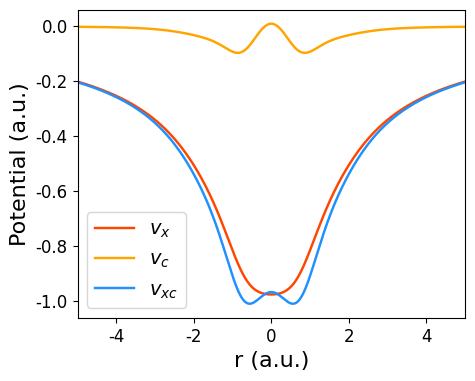

In [3]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vx_on_grid = vcoul_on_grid @ (mf_oep.vref_oep + mf_oep.vrest_oep)
vc_on_grid = vcoul_on_grid @ mf_oep.vrest_c_oep
vxc_on_grid = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vrest_c_oep + mf_oep.vref_oep)

plt.plot(coords[:, 2], vx_on_grid, color="orangered", label="$v_{x}$")
plt.plot(coords[:, 2], vc_on_grid, color="orange", label="$v_c$")
plt.plot(coords[:, 2], vxc_on_grid, color="dodgerblue", label="$v_{xc}$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

### 2.1 CO molecule: HOMO condition for exchange potential
We are going to compare results without and with HOMO condition for exchange potential. When HOMO condition is applied the negative of HOMO eigenvalue approximate ionization potential much better.

In [4]:
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
RI_BASIS = "aug-cc-pwCVQZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"
GEOM = "C 0.000000    0.000000   -0.646514; O 0.000000    0.000000    0.484886"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False  # symmetry must be disabled for OEP calculations

# Run RHF with density fitting to obtain reference orbitals and integrals
mf = scf.RHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# Set up and run the RPA-OEP self-consistent calculation
mf_oep = RPAOEP(mf, OEP_BASIS, RI_BASIS)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY            EDIFF             E_CORR
  0   -113.398657297562                         -0.63101665
  1   -113.567012782782     -0.168355485220     -0.80074535
  2   -113.562695935188      0.004316847594     -0.79108731
  3   -113.571228320422     -0.008532385234     -0.79973644
  4   -113.572007951512     -0.000779631090     -0.80013394
  5   -113.571639109799      0.000368841713     -0.79976041
  6   -113.571632194532      0.000006915267     -0.79975551
  7   -113.571634834483     -0.000002639950     -0.79975752
  8   -113.571634242782      0.000000591700     -0.79975689
  9   -113.571634202239      0.000000040543     -0.79975684
 10   -113.571634201149      0.000000001090     -0.79975684
SCF converged


In [5]:
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
RI_BASIS = "aug-cc-pwCVQZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"
GEOM = "C 0.000000    0.000000   -0.646514; O 0.000000    0.000000    0.484886"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False  # symmetry must be disabled for OEP calculations

# Run RHF with density fitting to obtain reference orbitals and integrals
mf = scf.RHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# Set up and run the RPA-OEP self-consistent calculation
mf_oep_homo = RPAOEP(mf, OEP_BASIS, RI_BASIS, use_HOMO_condition=True)
mf_oep_homo.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY            EDIFF             E_CORR
  0   -113.399079547049                         -0.63101665
  1   -113.567373178510     -0.168293631462     -0.80053675
  2   -113.562955810667      0.004417367844     -0.79117559
  3   -113.571323621562     -0.008367810895     -0.79966217
  4   -113.572100633460     -0.000777011899     -0.80006872
  5   -113.571745081799      0.000355551662     -0.79970672
  6   -113.571736257833      0.000008823965     -0.79970015
  7   -113.571739084005     -0.000002826171     -0.79970240
  8   -113.571738548615      0.000000535390     -0.79970183
  9   -113.571738511768      0.000000036847     -0.79970179
 10   -113.571738510418      0.000000001349     -0.79970179
SCF converged


In [6]:
# Function to make text in bold
def bold_text(text):
    return "\033[1m" + text + "\033[0m"


def print_eigs(eigs, no, nmax):
    """Function to print eigenvalues, HOMO energy, and LUMO-HOMO gap.

    Args:
      eig: Eigenvalues.
      no: Number of occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    if len(eigs.shape) == 1:  # closed-shell case
        for i in range(nmax):
            eig = f"{eigs[i]:7.3f}"
            if i + 1 <= no:
                eig = bold_text(eig)
            print(f"{i + 1:2}   {eig}")
        print(f"HOMO:      {eigs[no - 1]:7.3f}")
        print(f"LUMO-HOMO: {eigs[no] - eigs[no - 1]:7.3f}")
    else:
        for i in range(nmax):
            ea = f"{eigs[0, i]:7.3f}"
            eb = f"{eigs[1, i]:7.3f}"
            if i + 1 <= no[0]:
                ea = bold_text(ea)
            if i + 1 <= no[1]:
                eb = bold_text(eb)
            if i + 1 <= nmax:
                print(f"{i + 1:2}   {ea}  {eb}")
        print(f"HOMO:       {eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1] - 1]:7.3f}")
        print(f"LUMO-HOMO:  {eigs[0, no[0]] - eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1]] - eigs[1, no[1] - 1]:7.3f}")

In [7]:
print("Eigenvalues without HOMO condition")
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 10)

print()
print("Eigenvalues with HOMO condition")
print_eigs(mf_oep_homo.mf.mo_energy, mf_oep.nelec, 10)

Eigenvalues without HOMO condition
 1   -19.046
 2   -10.208
 3    -1.227
 4    -0.668
 5    -0.581
 6    -0.581
 7    -0.474
 8    -0.216
 9    -0.216
10    -0.114
HOMO:       -0.474
LUMO-HOMO:   0.258

Eigenvalues with HOMO condition
 1   -19.124
 2   -10.277
 3    -1.298
 4    -0.740
 5    -0.653
 6    -0.653
 7    -0.545
 8    -0.286
 9    -0.286
10    -0.151
HOMO:       -0.545
LUMO-HOMO:   0.259


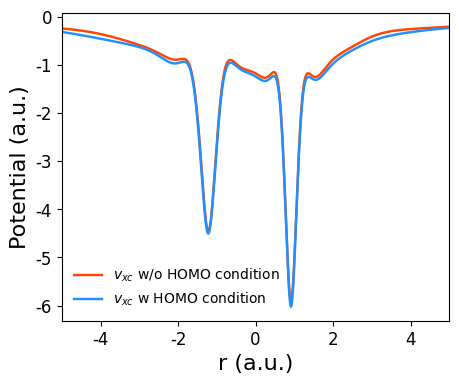

In [8]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vxc_on_grid = vcoul_on_grid @ (mf_oep.vref_oep + mf_oep.vrest_oep + mf_oep.vrest_c_oep)
vxc_on_grid_homo = vcoul_on_grid @ (mf_oep_homo.vref_oep + mf_oep_homo.vrest_oep + mf_oep_homo.vrest_c_oep)

plt.plot(coords[:, 2], vxc_on_grid, color="orangered", label="$v_{xc}$ w/o HOMO condition")
plt.plot(coords[:, 2], vxc_on_grid_homo, color="dodgerblue", label="$v_{xc}$ w HOMO condition")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False, fontsize=10)
plt.show()

## 3. Calculations for open-shell systems

### 3.1 N atom: spin-unrestricted calculation

A common way to perform Kohn-Sham (KS) calculations for open-shell systems is based on the spin-unrestricted KS method, which uses two different sets of spatial orbitals for and electrons. This leads to two different effective KS potentials for the $\alpha$- and $\beta$-electrons.

In [9]:
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
RI_BASIS = "aug-cc-pwCVQZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"
GEOM = "N 0.0 0.0 0.0"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=3)
mol.verbose = 0
mol.symmetry = False

mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

mf_oep = OSRPAOEP(mf, OEP_BASIS, RI_BASIS)
mf_oep.run(maxit=50, thr_fai_oep=1.7e-2)

ITER        ENERGY            EDIFF             E_CORR
  0    -54.656040244921                         -0.25447102
  1    -54.717063911194     -0.061023666273     -0.31658255
  2    -54.718163749400     -0.001099838205     -0.31823459
  3    -54.718934135459     -0.000770386059     -0.31882457
  4    -54.718800504200      0.000133631259     -0.31869356
  5    -54.718803033633     -0.000002529433     -0.31869653
  6    -54.718803451523     -0.000000417890     -0.31869697
  7    -54.718803477398     -0.000000025874     -0.31869700
  8    -54.718803478154     -0.000000000757     -0.31869700
SCF converged


In [10]:
print("Eigenvalues from spin-unrestricted calculation")
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

Eigenvalues from spin-unrestricted calculation
 1   -14.299  -14.781
 2    -0.928   -0.792
 3    -0.495   -0.396
 4    -0.495   -0.396
 5    -0.495   -0.396
 6    -0.125   -0.119
 7    -0.079   -0.076
HOMO:        -0.495    -0.792
LUMO-HOMO:    0.370     0.397


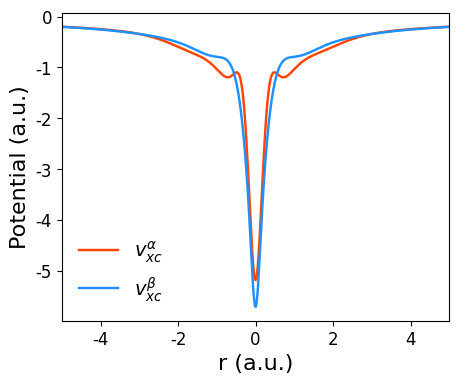

In [11]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vxc_on_grid_a = vcoul_on_grid @ (mf_oep.vrest_oep_a + mf_oep.vrest_c_oep_a + mf_oep.vref_oep_a)
vxc_on_grid_b = vcoul_on_grid @ (mf_oep.vrest_oep_b + mf_oep.vrest_c_oep_b + mf_oep.vref_oep_b)

plt.plot(coords[:, 2], vxc_on_grid_a, color="orangered", label="$v_{xc}^{\\alpha}$")
plt.plot(coords[:, 2], vxc_on_grid_b, color="dodgerblue", label="$v_{xc}^{\\beta}$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

### 3.2 N atom: spin-restricted calculation

An alternative approach to the spin-unrestricted KS method is to use one set of spatial orbitals for electrons of both spins. This approach is often referred to as the spin-restricted KS method for open-shell systems.

In [12]:
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
RI_BASIS = "aug-cc-pwCVQZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"
GEOM = "N 0.0 0.0 0.0"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=3)
mol.verbose = 0
mol.symmetry = False

mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

mf_oep = OSRPAOEP(mf, OEP_BASIS, RI_BASIS, spin_sym=True)
mf_oep.run(maxit=50, thr_fai_oep=1.7e-2)

ITER        ENERGY            EDIFF             E_CORR
  0    -54.650841688964                         -0.25447102
  1    -54.716079670425     -0.065237981462     -0.31979942
  2    -54.716173956792     -0.000094286366     -0.31991804
  3    -54.716211390538     -0.000037433746     -0.31994463
  4    -54.716201618620      0.000009771918     -0.31993496
  5    -54.716201729921     -0.000000111302     -0.31993507
  6    -54.716201724496      0.000000005425     -0.31993506
SCF converged


In [13]:
print("Eigenvalues from spin-restricted calculation")
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

Eigenvalues from spin-restricted calculation
 1   -14.390  -14.390
 2    -0.912   -0.912
 3    -0.484   -0.484
 4    -0.484   -0.484
 5    -0.484   -0.484
 6    -0.123   -0.123
 7    -0.078   -0.078
HOMO:        -0.484    -0.912
LUMO-HOMO:    0.360     0.428


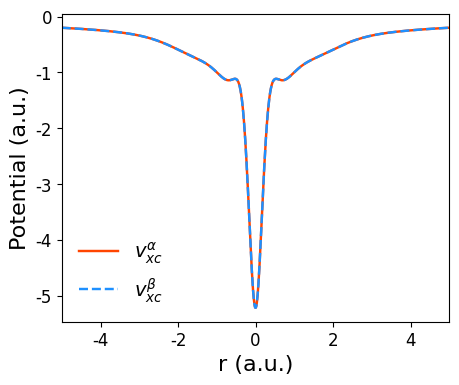

In [14]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vxc_on_grid_a = vcoul_on_grid @ (mf_oep.vrest_oep_a + mf_oep.vrest_c_oep_a + mf_oep.vref_oep_a)
vxc_on_grid_b = vcoul_on_grid @ (mf_oep.vrest_oep_b + mf_oep.vrest_c_oep_b + mf_oep.vref_oep_b)

plt.plot(coords[:, 2], vxc_on_grid_a, color="orangered", label="$v_{xc}^{\\alpha}$")
plt.plot(coords[:, 2], vxc_on_grid_b, "--", color="dodgerblue", label="$v_{xc}^{\\beta}$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

## 4. Concluding remarks
In this tutorial, we explored self-consistent random phase approximation calculations. We considered both closed- and open-shell systems. For closed-shell systems, we considered the use of HOMO condition for exchange potential. For the open-shell system, the N atom, we performed both spin-unrestricted and spin-restricted calculations.

As a post-processing of calculations, we accessed and printed orbital energies and explored how to plot the resulting exchange-correlation potential and its individual contributions.

---

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/PyOEP/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/PyOEP/)  If you found this tutorial helpful, consider ⭐-ing the repository.